## The Model

from : https://www.tensorflow.org/probability/examples/Probabilistic_PCA

Probabilistic principal components analysis (PCA) is a
dimensionality reduction technique that
analyzes data via a lower dimensional latent space
([Tipping and Bishop 1999](#1)). It is often
used when there are missing values in the data or for multidimensional
scaling.


Consider a data set $\mathbf{X} = \{\mathbf{x}_n\}$ of $N$ data
points, where each data point is $D$-dimensional, $\mathbf{x}_n \in
\mathbb{R}^D$. We aim to represent each $\mathbf{x}_n$ under a latent
variable $\mathbf{z}_n \in \mathbb{R}^K$ with lower dimension, $K <
D$. The set of principal axes $\mathbf{W}$ relates the latent variables to
the data.

Specifically, we assume that each latent variable is normally distributed,

$$
\begin{equation*}
\mathbf{z}_n \sim N(\mathbf{0}, \mathbf{I}).
\end{equation*}
$$

The corresponding data point is generated via a projection,

$$
\begin{equation*}
\mathbf{x}_n \mid \mathbf{z}_n
\sim N(\mathbf{W}\mathbf{z}_n, \sigma^2\mathbf{I}),
\end{equation*}
$$

where the matrix $\mathbf{W}\in\mathbb{R}^{D\times K}$ are known as
the principal axes. In probabilistic PCA, we are typically interested in
estimating the principal axes $\mathbf{W}$ and the noise term
$\sigma^2$.

Probabilistic PCA generalizes classical PCA. Marginalizing out the the
latent variable, the distribution of each data point is

$$
\begin{equation*}
\mathbf{x}_n \sim N(\mathbf{0}, \mathbf{W}\mathbf{W}^\top + \sigma^2\mathbf{I}).
\end{equation*}
$$

Classical PCA is the specific case of probabilistic PCA when the
covariance of the noise becomes infinitesimally small, $\sigma^2 \to 0$.

We set up our model below. In our analysis, we assume $\sigma$ is known, and
instead of point estimating $\mathbf{W}$ as a model parameter, we
place a prior over it in order to infer a distribution over principal
axes.

# Simulation

In [4]:
import os
import sys
newPath = os.path.dirname(os.path.abspath(""))
if newPath not in sys.path:
    sys.path.append(newPath)
from BayesForge import bf
import matplotlib.pyplot as plt
from jax import vmap
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
m = bf(platform='cpu')



# --- 1. Define and Generate the Hierarchical Data ---
# (This part is correct and remains unchanged)
def sim_data_hierarchical(data_dim, num_datapoints, stddv_datapoints, seed=0):
    latent_dim = 4
    latent_scales = jnp.array([10.0, 5.0, 2.0, 0.5])
    w = m.dist.normal(0, 1, shape=(data_dim, latent_dim), name='w', sample=True, seed=seed)
    z = m.dist.normal(0, 1, shape=(latent_dim, num_datapoints), name='z', sample=True, seed=seed)
    z_scaled = z * latent_scales[:, None]
    x = m.dist.normal(w @ z_scaled, stddv_datapoints, name='x', sample=True, seed=seed)
    return w, z_scaled, x

num_datapoints = 500
data_dim = 4
stddv_datapoints = 0.5
actual_w_h, actual_z_h, x_train_h = sim_data_hierarchical(data_dim, num_datapoints, stddv_datapoints, seed=20)

jax.local_device_count 24


## Model

In [5]:


# Model using simulated data
#def model(x_train, data_dim, latent_dim, num_datapoints): 
#    w = m.dist.normal(0, 1, shape=(data_dim, latent_dim), name='w')
#    z = m.dist.normal(0, 1, shape=(latent_dim, num_datapoints), name='z')
#    epsilon = m.dist.exponential(1, name='epsilon')
#    m.dist.normal(w @ z , epsilon, obs = x_train)  



In [6]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --- 1. Define and Generate the Hierarchical Data ---
# (This part is correct and remains unchanged)
def sim_data_hierarchical(data_dim, num_datapoints, stddv_datapoints, seed=0):
    latent_dim = 4
    latent_scales = jnp.array([10.0, 5.0, 2.0, 0.5])
    w = m.dist.normal(0, 1, shape=(data_dim, latent_dim), name='w', sample=True, seed=seed)
    z = m.dist.normal(0, 1, shape=(latent_dim, num_datapoints), name='z', sample=True, seed=seed)
    z_scaled = z * latent_scales[:, None]
    x = m.dist.normal(w @ z_scaled, stddv_datapoints, name='x', sample=True, seed=seed)
    return w, z_scaled, x

num_datapoints = 500
data_dim = 4
stddv_datapoints = 0.5
actual_w_h, actual_z_h, x_train_h = sim_data_hierarchical(data_dim, num_datapoints, stddv_datapoints, seed=20)



In [7]:

# --- 2. THE FINAL CORRECTED MODEL DEFINITION ---
def model_final(x_train, data_dim, latent_dim, num_datapoints):
    """
    Probabilistic PCA model with ARD (Automatic Relevance Determination) prior on weights and a correctly defined noise model. ARD helps in automatic relevance determination of latent dimensions, by allowing the model to learn which dimensions are important.
    Args:
        x_train: Observed data matrix of shape (data_dim, num_datapoints).
        data_dim: Dimensionality of the observed data.
        latent_dim: Dimensionality of the latent space.
        num_datapoints: Number of data points.
    """
    # ARD Prior on w (This part is correct)
    alpha = m.dist.gamma(.05, 1e-3, shape=(latent_dim,), name='alpha')
    w = m.dist.normal(0, 1. / jnp.sqrt(alpha)[None, :], shape=(data_dim, latent_dim), name='w')

    # Prior on z (This part is correct)
    z = m.dist.normal(0, 1., shape=(latent_dim, num_datapoints), name='z')

    # --- CORRECTED NOISE MODEL ---
    # Prior on the precision (1 / variance)
    precision = m.dist.gamma(1.0, 1.0, name='precision')
    # The standard deviation is 1 / sqrt(precision)
    stddv = 1. / jnp.sqrt(precision)

    # Use the correctly defined standard deviation in the likelihood
    m.dist.normal(w @ z, stddv, obs=x_train)



Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:02<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:08<01:56, 16.27it/s]


Running chain 0:  10%|█         | 200/2000 [00:17<02:18, 12.97it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:26<02:19, 12.19it/s]


Running chain 0:  20%|██        | 400/2000 [00:35<02:15, 11.77it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:43<02:06, 11.90it/s]


Running chain 0:  30%|███       | 600/2000 [00:51<01:52, 12.40it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:58<01:40, 12.98it/s]


Running chain 0:  40%|████      | 800/2000 [01:06<01:34, 12.76it/s]


Running chain 0:  50%|█████     | 1000/2000 [01:20<01:16, 13.13it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [01:29<01:12, 12.50it/s]


Running chain 0:  60%|██████    | 1200/2000 [01:38<01:06, 12.03it/s]


Running chain 0:  65%|██████▌   | 1300/2000 [01:47<00:59, 11.67it/s]


Running chain 0:  70%|███████   | 14

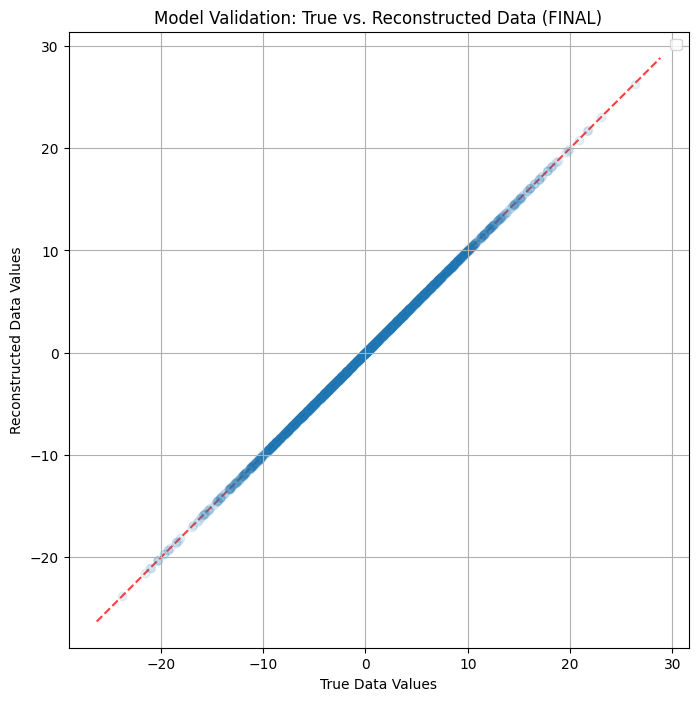

True noise standard deviation: 0.5
Inferred noise standard deviation: 0.0636


In [8]:

# --- 3. Fit the Final Model ---
m.data_on_model = dict(
    x_train=x_train_h,
    data_dim=data_dim,
    latent_dim=4,
    num_datapoints=num_datapoints
)
m.fit(model_final)

# --- 4. Correctly Calculate and Plot the Reconstruction ---
# (This logic was already correct from the previous step)
w_samples = m.posteriors['w']
z_samples = m.posteriors['z']

reconstruct_one_sample = lambda w, z: w @ z
x_reconstructed_samples = jax.vmap(reconstruct_one_sample)(w_samples, z_samples)
x_reconstructed_correct = x_reconstructed_samples.mean(axis=0)

plt.figure(figsize=(8, 8))
plt.scatter(x_train_h.flatten(), x_reconstructed_correct.flatten(), alpha=0.1)
x_lims, y_lims = plt.xlim(), plt.ylim()
all_lims = jnp.array([x_lims, y_lims])
lims = [jnp.min(all_lims), jnp.max(all_lims)]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
plt.xlabel("True Data Values")
plt.ylabel("Reconstructed Data Values")
plt.title("Model Validation: True vs. Reconstructed Data (FINAL)")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

# Optional: Check if the model learned the correct noise level
posterior_stddv = 1. / jnp.sqrt(m.posteriors['precision'].mean())
print(f"True noise standard deviation: {stddv_datapoints}")
print(f"Inferred noise standard deviation: {posterior_stddv:.4f}")

# Estimations are inverted due to **Sign Ambiguity in PCA**: 



Principal Component Analysis (PCA) identifies directions (principal components) that capture the maximum variance in the data. However, the orientation of these components is not unique; both a vector and its negation represent the same principal direction. This means that if 𝑤 is a principal component, −𝑤 is equally valid.

To resolve this issue, we can align the signs of the estimated parameters with the true parameters before comparison. 

Compute the Dot Product: Calculate the dot product between the true parameters and the estimated parameters. This will help determine the relative orientation.

Align Signs: If the dot product is negative, multiply the estimated parameters by -1 to align them with the true parameters.


In [15]:
true_params

Array([[  9.26846009,  -6.67393115,   7.76223096, ...,   4.02416752,
         10.57252244,   6.32476871],
       [ -3.33722931,  -0.18462268,   4.65360604, ...,   1.54251535,
         13.63030758,  -2.60313385],
       [-14.43829257,   4.95644978,  -7.23348051, ...,  -1.85973621,
          8.35023543,  -9.60407951],
       [  7.75712619,  -1.87507846,   7.35294663, ...,   1.09053935,
         -3.44766513,   4.76676856]], dtype=float64)

In [18]:
z_samples.shape

(4000, 4, 500)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


true_params = jnp.array(x_train_h)      
estimated_params = jnp.array(x_reconstructed_correct)

# Compute dot product
dot_product = jnp.dot(true_params, estimated_params)

# Align signs if necessary
if dot_product < 0:
    estimated_params = -estimated_params

# Plot the aligned parameters
plt.scatter(true_params, estimated_params, alpha=0.7)
plt.plot([min(true_params), max(true_params)], [min(true_params), max(true_params)], 'r--')
plt.xlabel('True Parameters')
plt.ylabel('Estimated Parameters')
plt.title('True vs. Estimated Parameters After Sign Alignment')
plt.show()

# Iris data

In [26]:
from sklearn import datasets

iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [28]:
m.df.shape

(150, 4)

In [32]:
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

jax.local_device_count 24
ARD is in development. Use with caution.
ARD is in development. Use with caution.


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:02<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:03<00:21, 90.15it/s]



Running chain 0:  10%|█         | 200/2000 [00:04<00:17, 102.74it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:04<00:12, 131.91it/s]


Running chain 0:  20%|██        | 400/2000 [00:05<00:11, 140.85it/s]





Running chain 0:  25%|██▌       | 500/2000 [00:06<00:10, 141.20it/s]



Running chain 0:  30%|███       | 600/2000 [00:07<00:11, 127.00it/s]





Running chain 0:  35%|███▌      | 700/2000 [00:08<00:10, 123.13it/s]

Running chain 0:  40%|████      | 800/2000 [00:08<00:09, 130.55it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:09<00:08, 132.47it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:10<00:07, 128.44it/s]

Running chain 0:  55%|█████▌    | 1100/2000 [00:11<00:07, 114.99it/s]




Running chain 0:  60%|██████    | 1200/2000 [00:12<00:08, 98.51it/s] 


Running chain 0:  

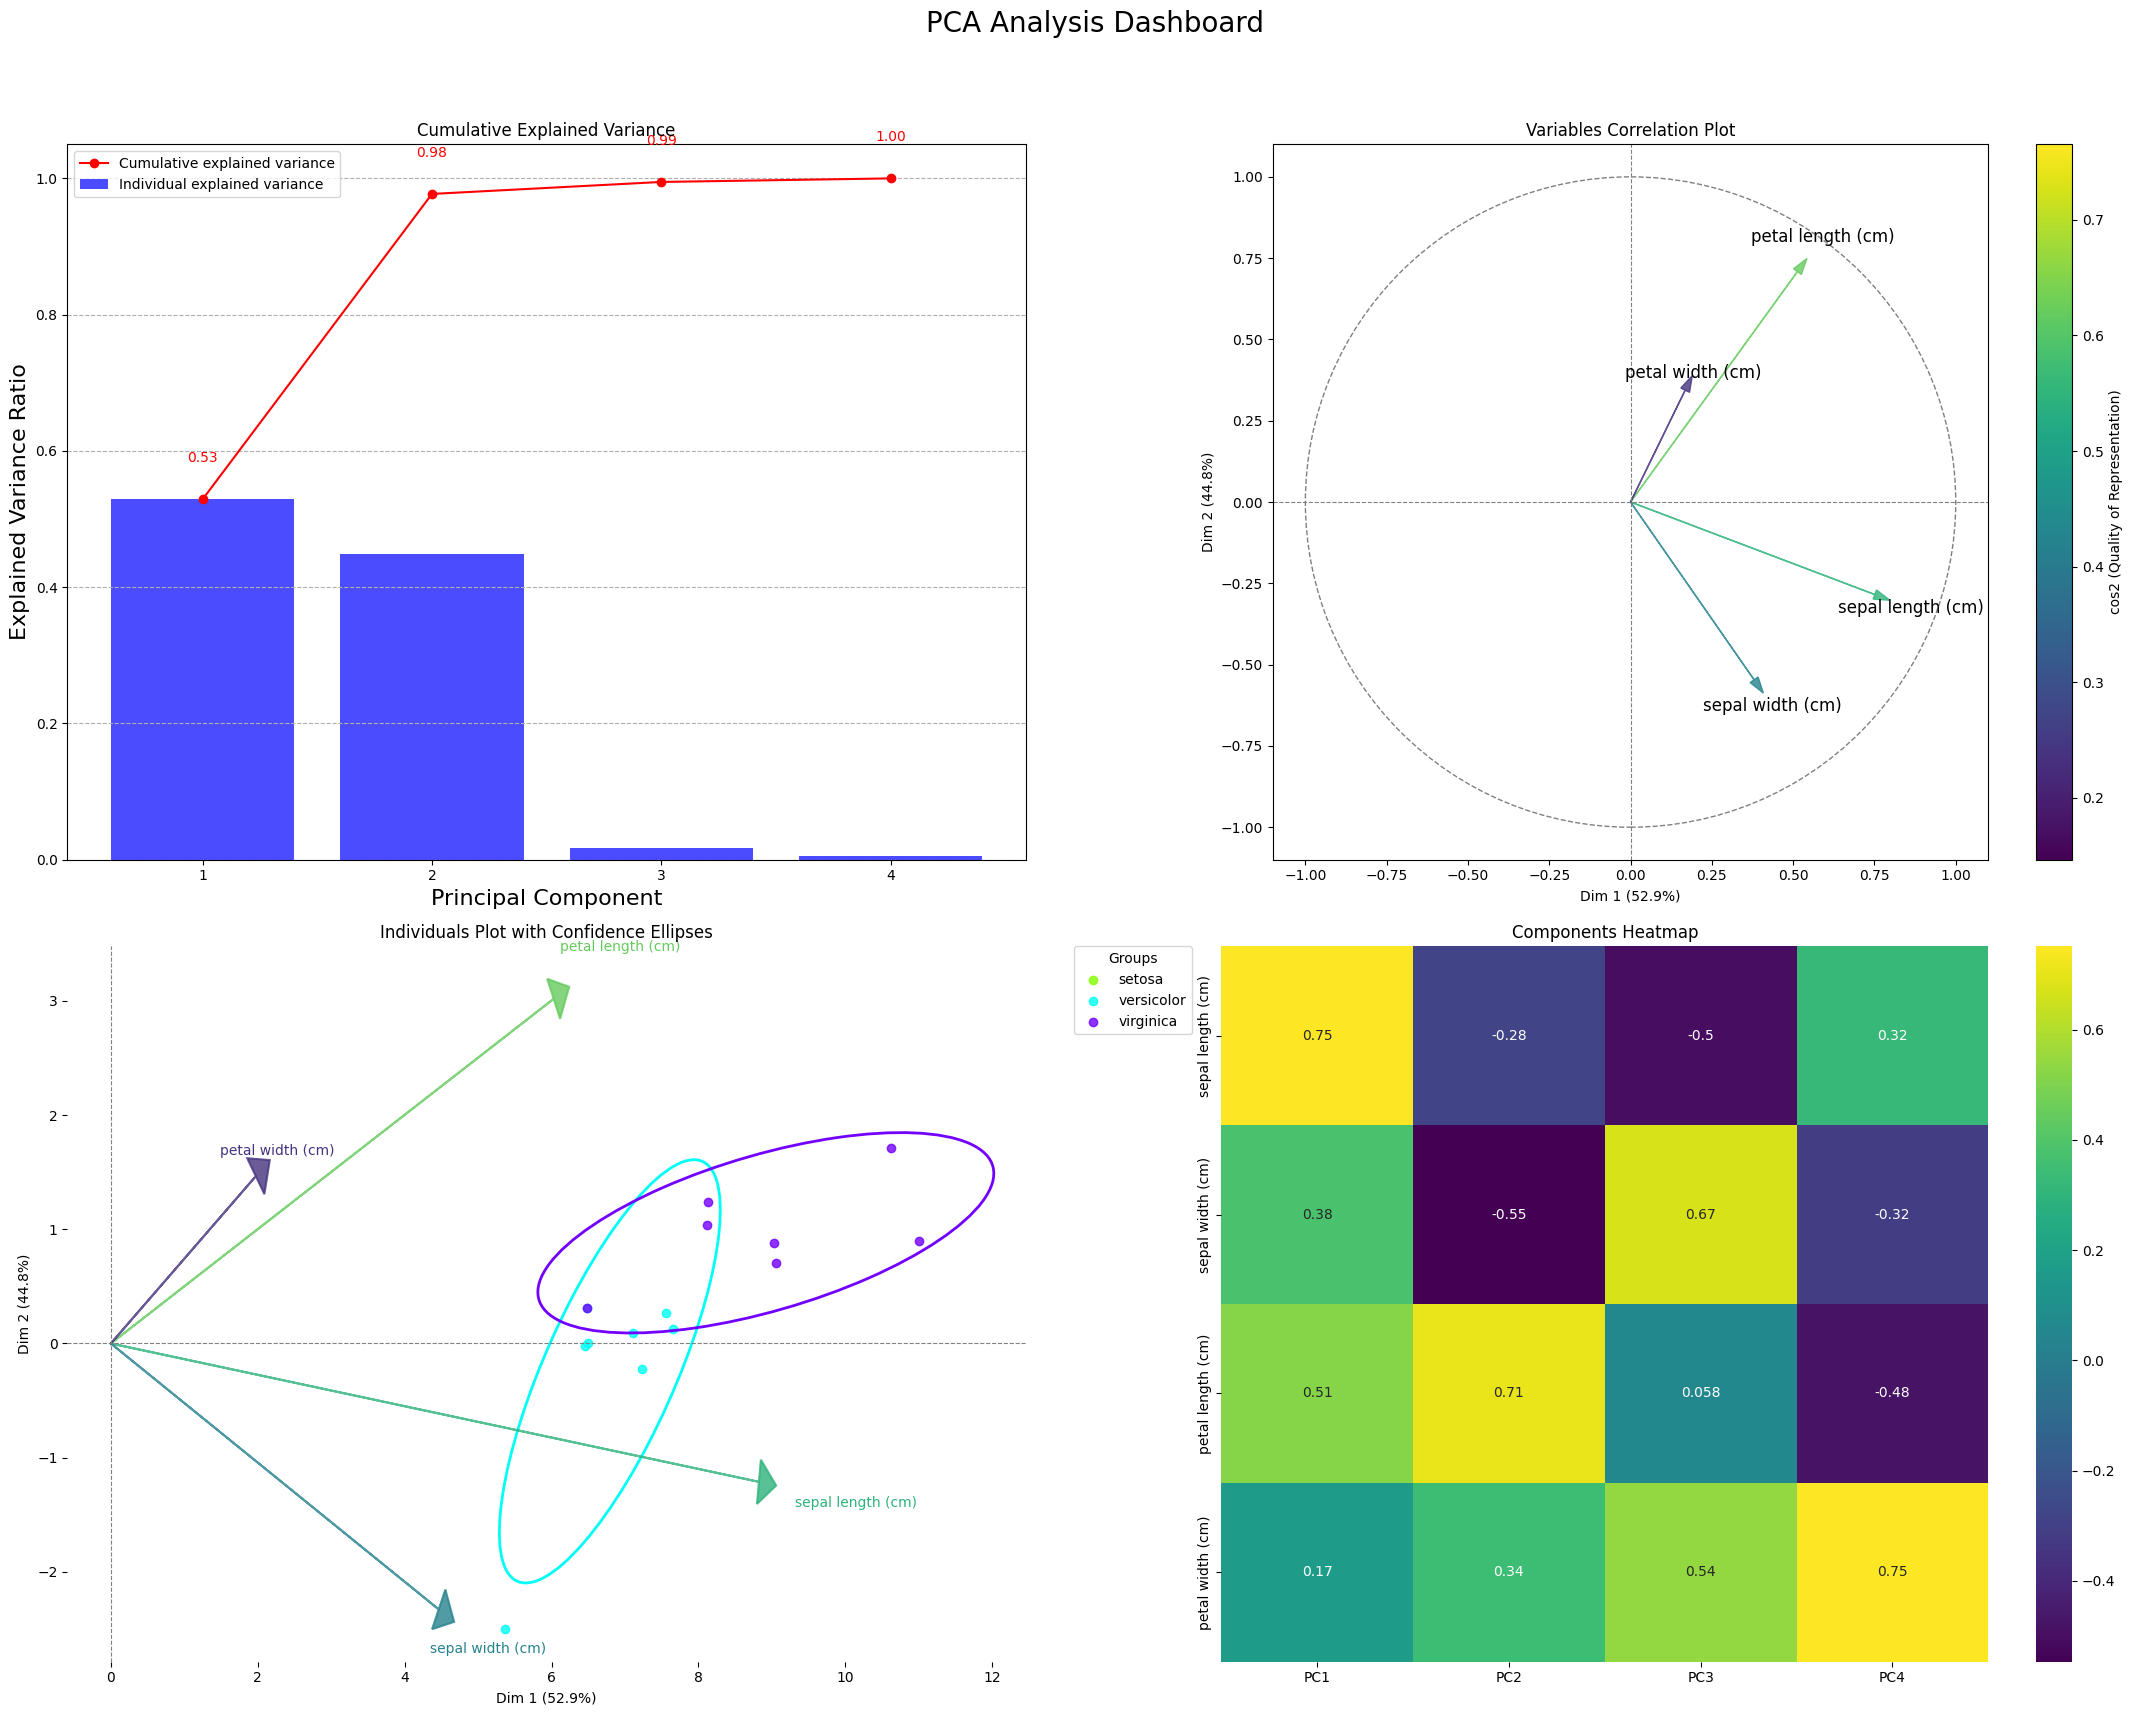

In [38]:
from sklearn.datasets import load_iris
from BayesForge import bf
m=bf()
m.df = iris['data']
m.data_on_model = dict(
    X=jnp.array(m.df)
)
m.fit(m.models.pca(type="ARD")) # or robust, sparse, classic, sparse_robust_ard
m.models.pca.plot(
    X=m.df,
    y=m.df, 
    feature_names=iris['feature_names'], 
    target_names=iris['target_names'],
)

In [39]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import numpy as np # For plotting compatibility
import os
import sys
newPath = os.path.dirname(os.path.abspath(""))
if newPath not in sys.path:
    sys.path.append(newPath)

import matplotlib.pyplot as plt
from BayesForge import bf
m=bf()


# --- Load and Scale Data (from scratch with JAX) ---
iris = load_iris()
X_raw = jnp.array(iris.data)
y = jnp.array(iris.target)
feature_names = iris.feature_names
target_names = iris.target_names
def scale_data(X):
    """Standardizes features by removing the mean and scaling to unit variance."""
    mean = jnp.mean(X, axis=0)
    std = jnp.std(X, axis=0)
    return (X - mean) / std, mean, std

X_scaled, data_mean, data_std = scale_data(X_raw)
X_scaled.shape

jax.local_device_count 24


(150, 4)

Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:03<00:23, 81.48it/s]


Running chain 0:  10%|█         | 200/2000 [00:04<00:19, 93.94it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:04<00:16, 105.35it/s]


Running chain 0:  20%|██        | 400/2000 [00:05<00:14, 108.53it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:06<00:14, 100.77it/s]


Running chain 0:  30%|███       | 600/2000 [00:07<00:13, 103.92it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:08<00:11, 109.57it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:10<00:09, 119.64it/s]




Running chain 0:  55%|█████▌    | 1100/2000 [00:11<00:07, 122.10it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:12<00:06, 119.54it/s]

Running chain 0:  65%|██████▌   | 1300/2000 [00:13<00:05, 120.71it/s]


Running chain 0:  75%|███████▌  | 1500/2000 [00:14<00:03, 130.12it/s]


Running chain 0:  80%|███

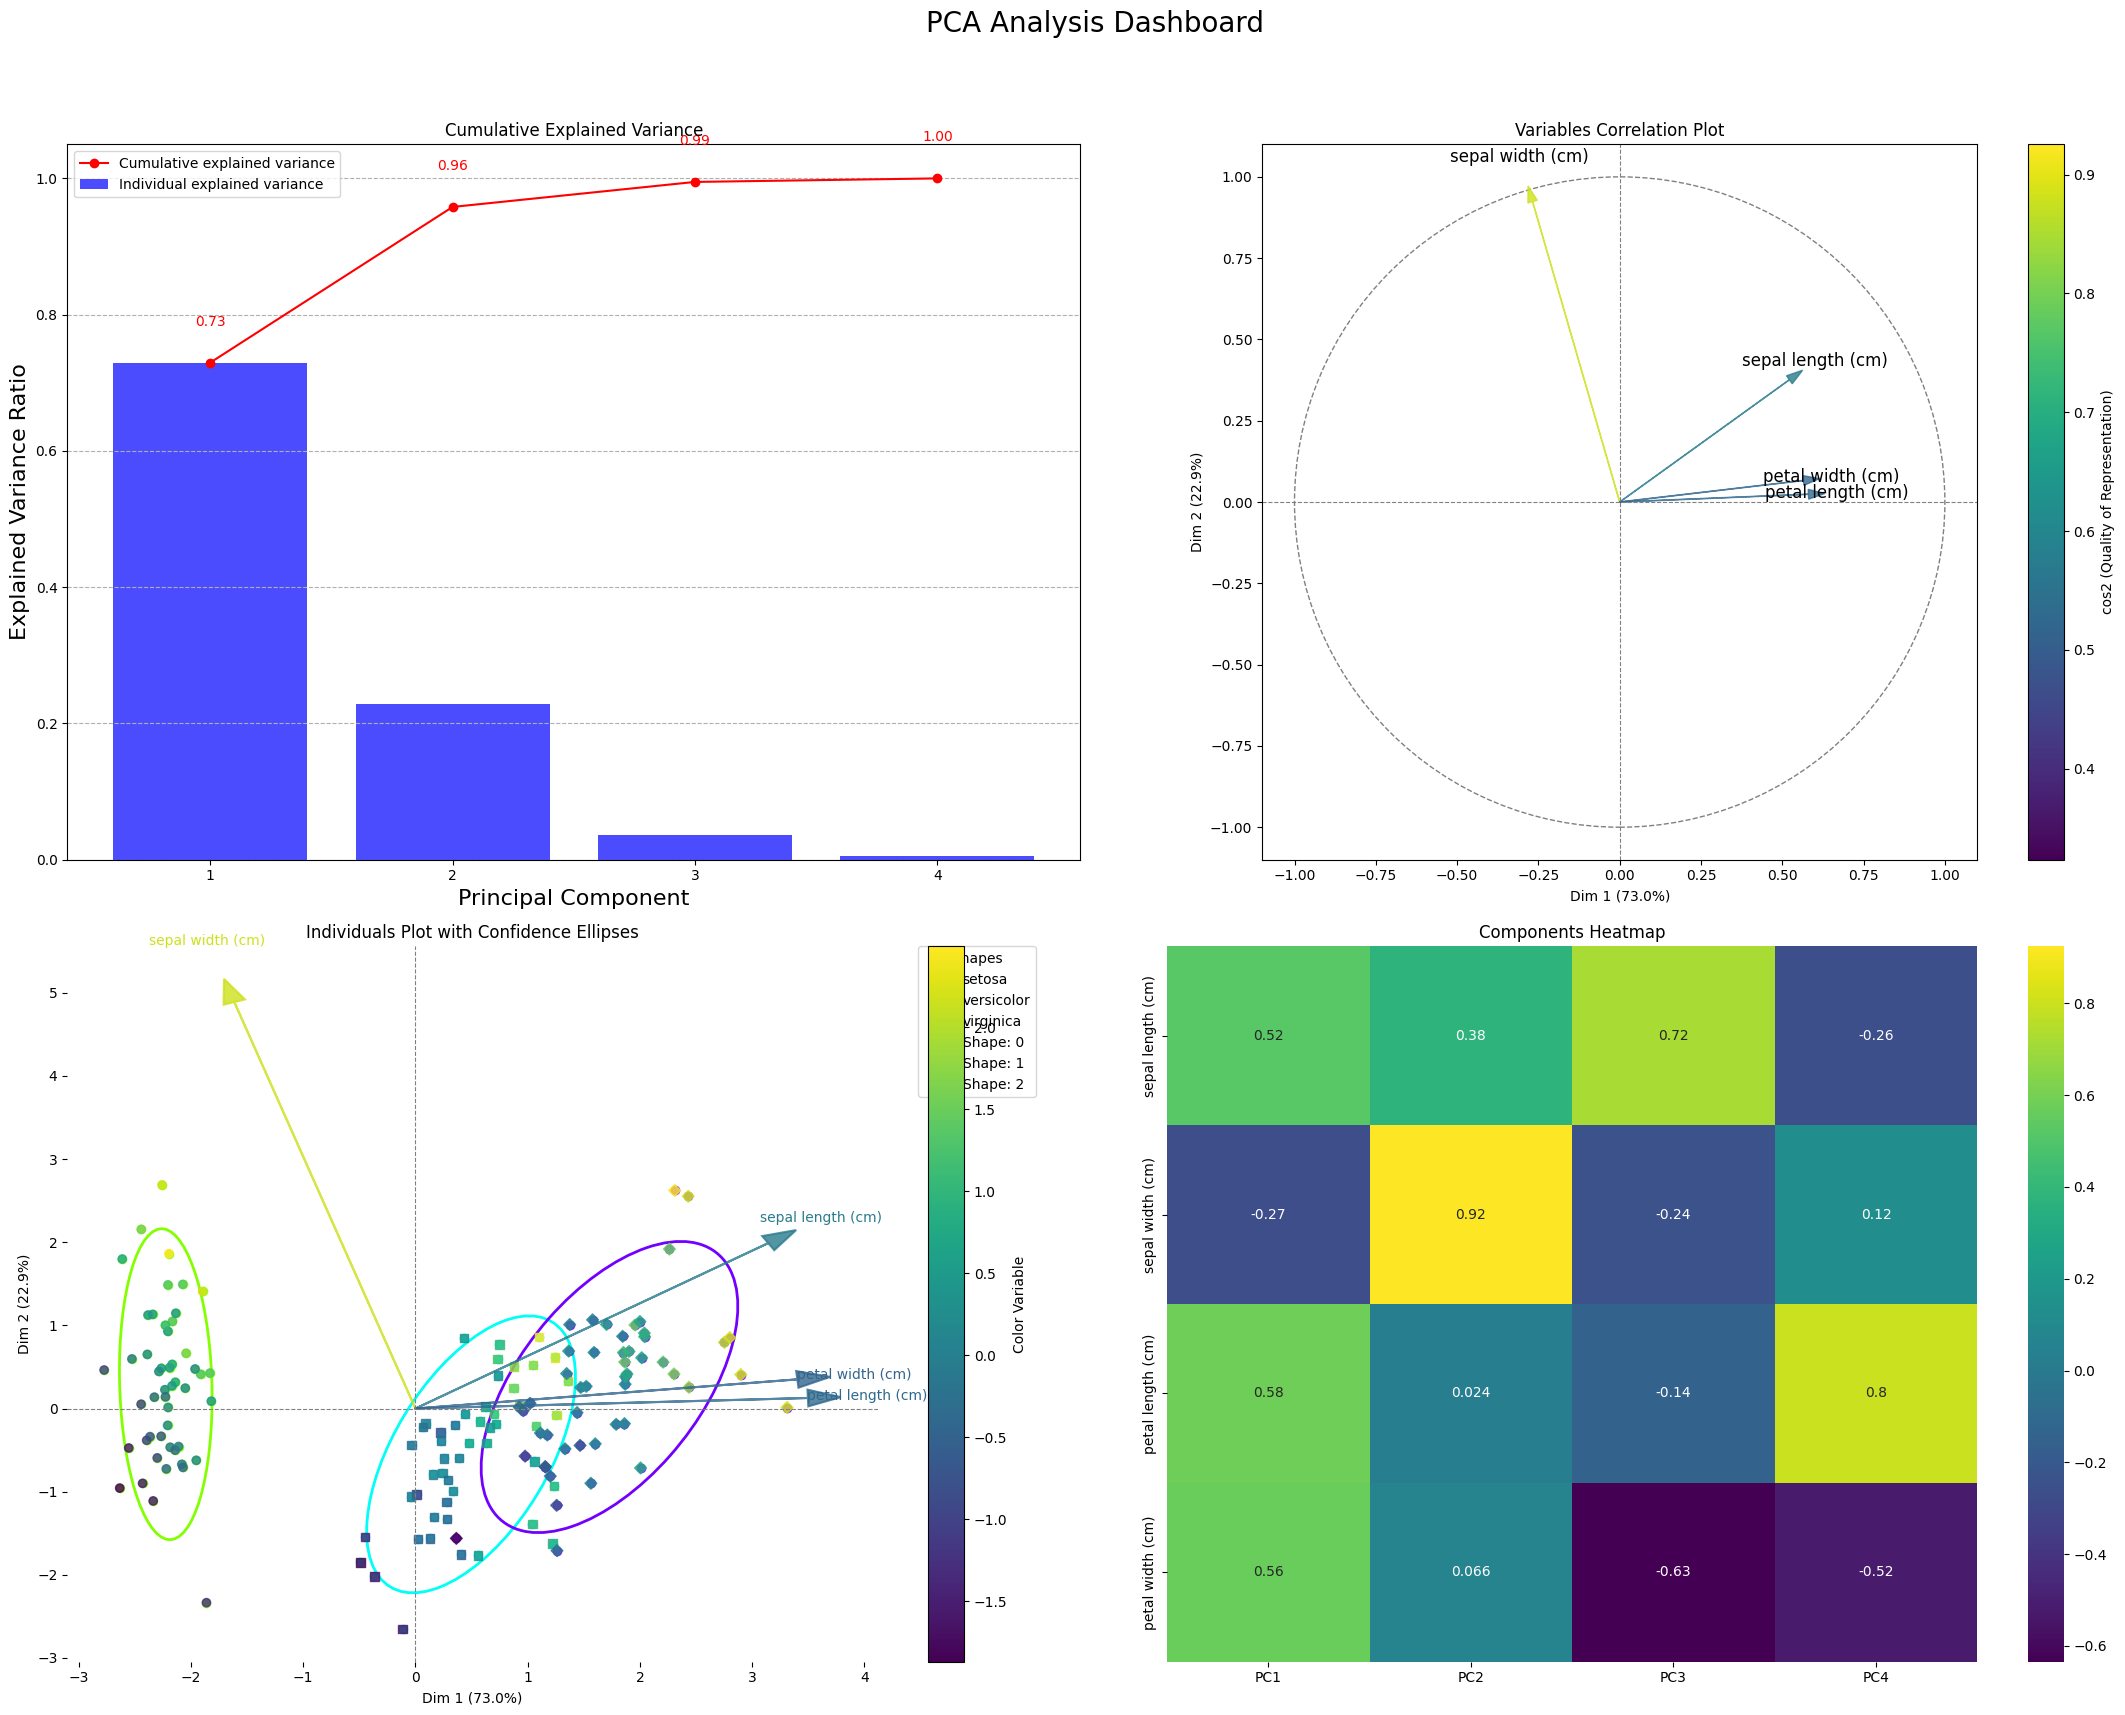

In [40]:
m.data_on_model = dict(X=X_scaled)
m.fit(m.models.pca())
m.models.pca.plot(
    X=X_scaled,
    y=y, 
    feature_names=feature_names, 
    target_names=target_names,
    color_var=X_scaled[:,0],
    shape_var=y
)

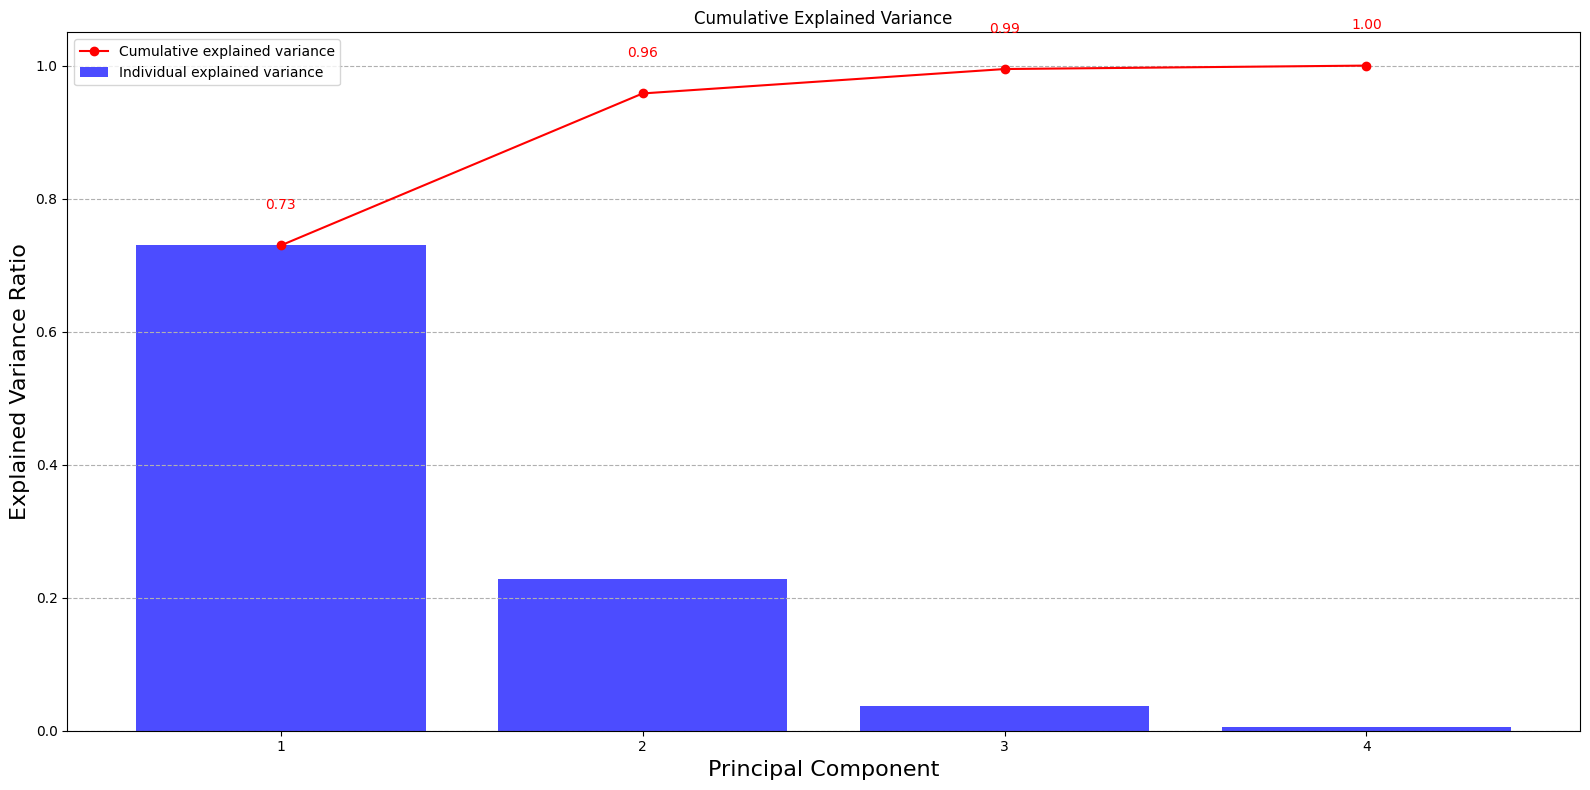

In [41]:
m.models.pca.cumulative_variance(X_scaled)

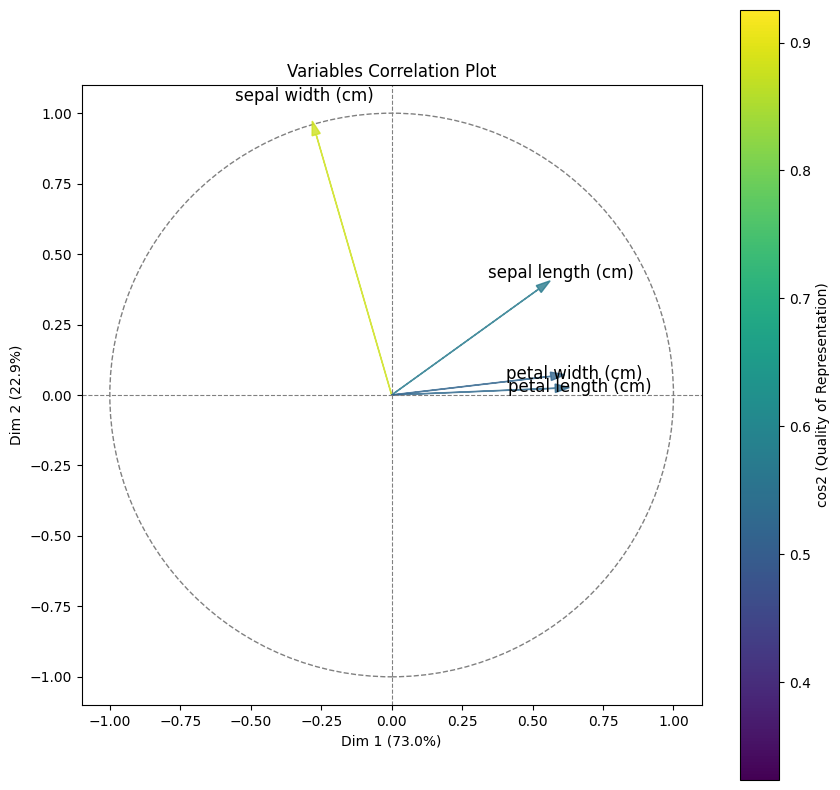

In [42]:
m.models.pca.variable_correlation(feature_names)

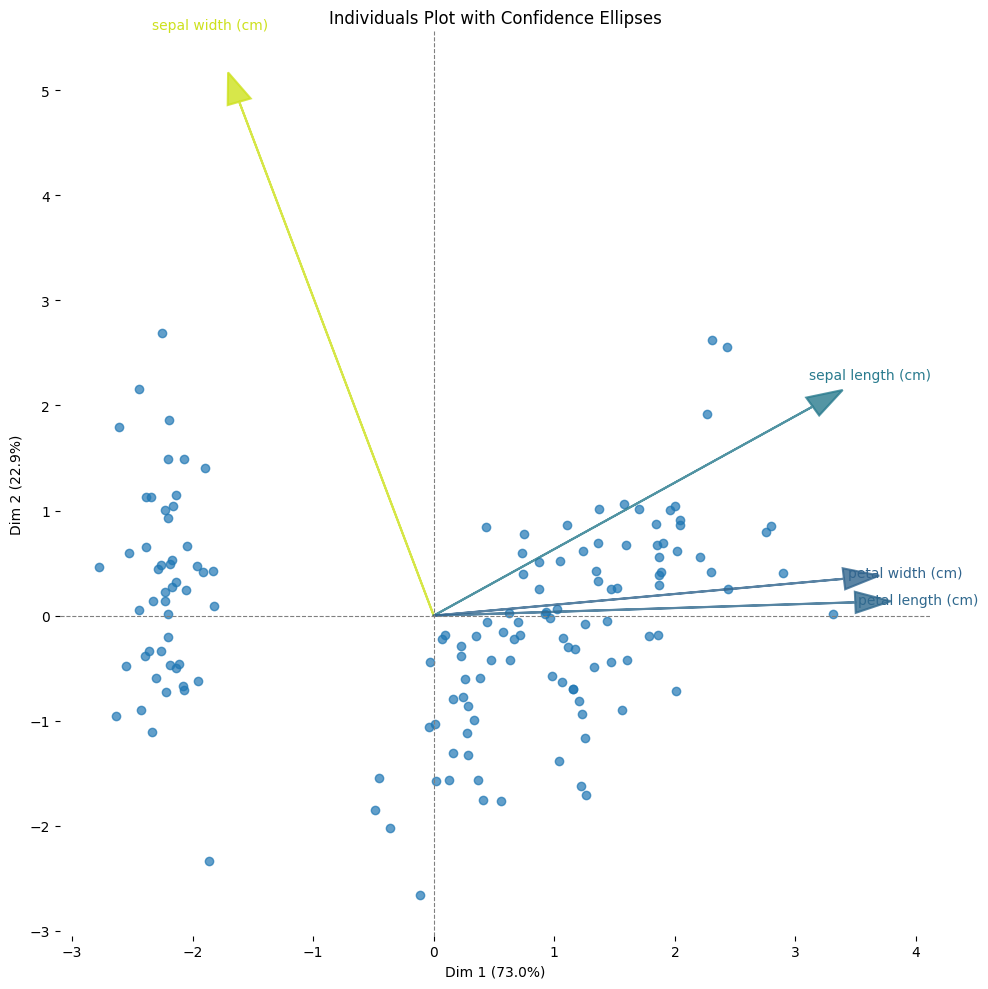

<Axes: title={'center': 'Individuals Plot with Confidence Ellipses'}, xlabel='Dim 1 (73.0%)', ylabel='Dim 2 (22.9%)'>

In [43]:
m.models.pca.individual_correlation(feature_names=feature_names)

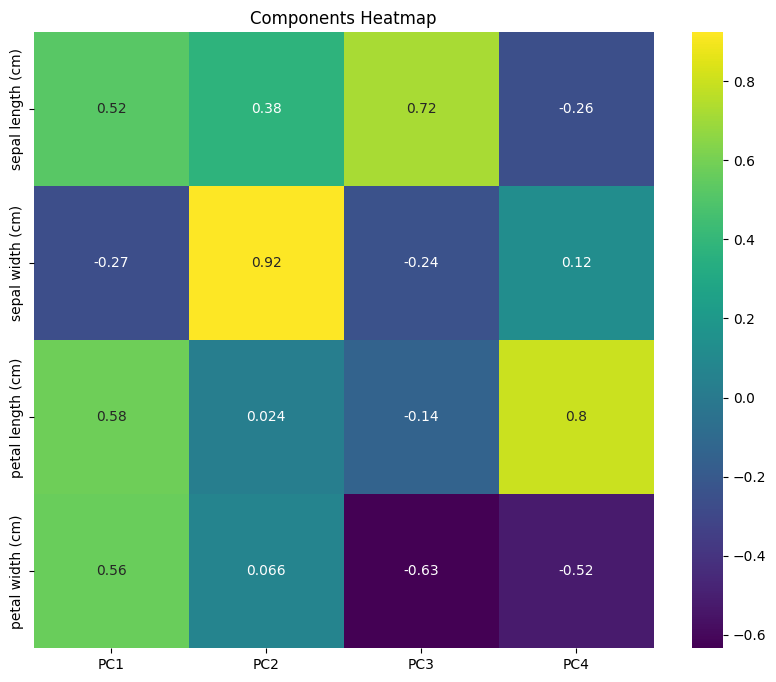

In [44]:
m.models.pca.components(feature_names=feature_names)

# Comparing sklearn results

In [45]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
pca = PCA(n_components=4)
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

<Axes: >

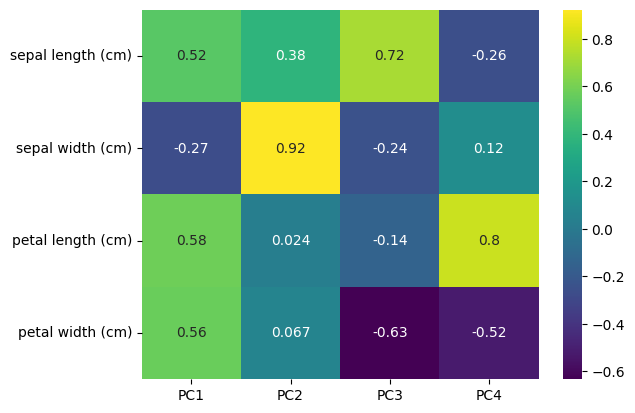

In [46]:
sklearn_comps = pca.components_.T
pc_names = [f'PC{i+1}' for i in range(sklearn_comps.shape[1])]
df_sklearn = pd.DataFrame(sklearn_comps, index=feature_names, columns=pc_names)
sns.heatmap(df_sklearn, annot=True, cmap='viridis')

# PCA variants

jax.local_device_count 24
robust is in development. Use with caution.
robust is in development. Use with caution.


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:02<?, ?it/s]



Running chain 0:   5%|▌         | 100/2000 [00:04<00:44, 42.85it/s]


Running chain 0:  10%|█         | 200/2000 [00:06<00:34, 51.88it/s]

Running chain 0:  15%|█▌        | 300/2000 [00:07<00:27, 60.75it/s]


Running chain 0:  20%|██        | 400/2000 [00:09<00:25, 62.59it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:10<00:22, 66.05it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:13<00:18, 68.49it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:16<00:16, 67.31it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:18<00:15, 63.42it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:21<00:11, 69.26it/s]

Running chain 0:  75%|███████▌  | 1500/2000 [00:24<00:06, 78.15it/s]

Running chain 0:  95%|█████████▌| 1900/2000 [00:28<00:01, 91.29it/s]

Running chain 0: 100%|██████████| 2000/2000 [00:30<00:00, 66.57it/s]







Running chain 1: 100%|██████████|

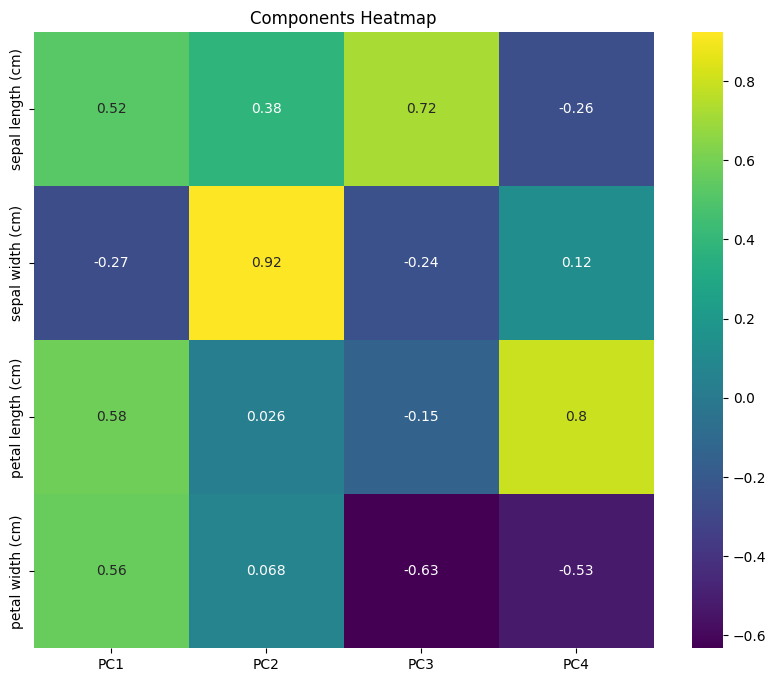

In [47]:
m = bf(platform='cpu')
m.data_on_model = dict(X=X_scaled)
m.fit(m.models.pca(type='robust'))
m.models.pca.components(feature_names=feature_names)

jax.local_device_count 24
sparse is in development. Use with caution.
sparse is in development. Use with caution.


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:02<?, ?it/s]



Running chain 0:   5%|▌         | 100/2000 [00:03<00:21, 86.44it/s]


Running chain 0:  10%|█         | 200/2000 [00:04<00:15, 118.90it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:04<00:12, 135.45it/s]

Running chain 0:  20%|██        | 400/2000 [00:05<00:11, 138.34it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:06<00:11, 132.38it/s]


Running chain 0:  30%|███       | 600/2000 [00:07<00:10, 132.26it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:07<00:09, 133.49it/s]


Running chain 0:  40%|████      | 800/2000 [00:08<00:08, 134.23it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:09<00:08, 135.80it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:09<00:07, 136.50it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [00:10<00:06, 137.09it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:11<00:05, 134.26it/s]


Running chain 0:  65%|████

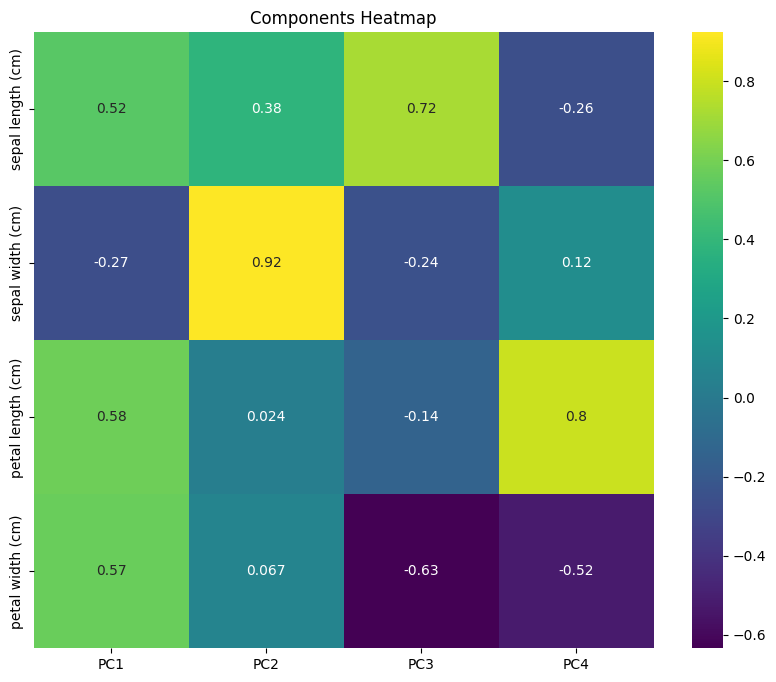

In [49]:
m = bf(platform='cpu')
m.data_on_model = dict(X=X_scaled)
m.fit(m.models.pca(type='sparse'))
m.models.pca.components(feature_names=feature_names)

jax.local_device_count 24


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]



Running chain 0:   5%|▌         | 100/2000 [00:03<00:27, 70.01it/s]

Running chain 0:  10%|█         | 200/2000 [00:04<00:20, 88.75it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:05<00:15, 106.38it/s]


Running chain 0:  20%|██        | 400/2000 [00:05<00:14, 112.18it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:06<00:13, 109.05it/s]


Running chain 0:  30%|███       | 600/2000 [00:07<00:12, 109.25it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:08<00:12, 105.19it/s]


Running chain 0:  40%|████      | 800/2000 [00:09<00:11, 108.96it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:10<00:09, 111.94it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:11<00:09, 106.24it/s]






Running chain 0:  55%|█████▌    | 1100/2000 [00:13<00:11, 80.97it/s] 





Running chain 0:  60%|██████    | 1200/2000 [00:15<00:12, 63.02it/s]








Running chain 0

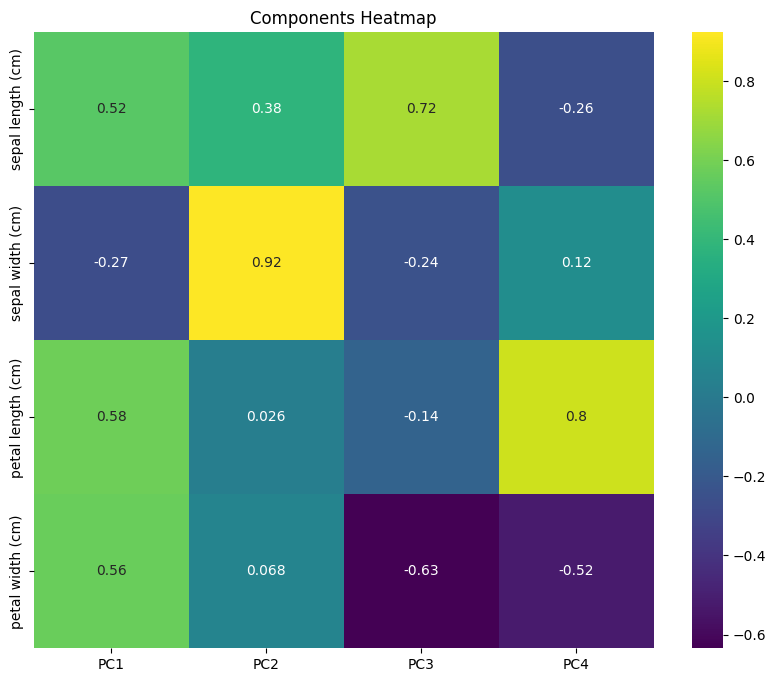

In [50]:
m = bf(platform='cpu')
m.data_on_model = dict(X=X_scaled)
m.fit(m.models.pca(type='classic'))
m.models.pca.components(feature_names=feature_names)

jax.local_device_count 24
sparse_robust_ard is in development. Use with caution.
sparse_robust_ard is in development. Use with caution.


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:03<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:06<00:46, 41.22it/s]


Running chain 0:  10%|█         | 200/2000 [00:07<00:32, 55.27it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:09<00:28, 60.11it/s]



Running chain 0:  20%|██        | 400/2000 [00:10<00:24, 65.16it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:12<00:23, 63.37it/s]


Running chain 0:  30%|███       | 600/2000 [00:13<00:20, 68.12it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:14<00:19, 66.73it/s]




Running chain 0:  40%|████      | 800/2000 [00:16<00:18, 64.73it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:17<00:15, 70.10it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:19<00:14, 69.16it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [00:21<00:15, 59.28it/s]



Running chain 0:  60%|██████    | 1200/2000 [00:24<00:15, 51.18it/s]




Running chain 0:  65%|██████▌  

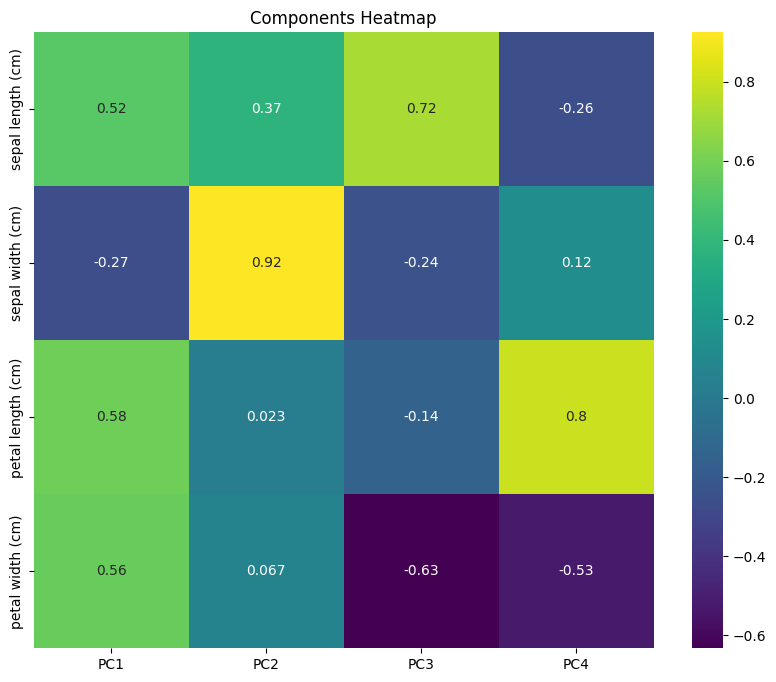

In [51]:
m = bf(platform='cpu')
m.data_on_model = dict(X=X_scaled)
m.fit(m.models.pca(type='sparse_robust_ard'))
m.models.pca.components(feature_names=feature_names)

# References
https://www.tensorflow.org/probability/examples/Probabilistic_PCA

<a name='1'></a>[1]: Michael E. Tipping and Christopher M. Bishop. Probabilistic principal component analysis. Journal of the Royal Statistical Society: Series B (Statistical Methodology), 61(3): 611-622, 1999.